In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

import sys
sys.path.append("../")
from src.generative_models import get_pt_utility

In [ ]:
%load_ext autoreload
%autoreload 2

RNG = np.random.default_rng(2024)
np.set_printoptions(suppress=True)

In [ ]:
FONTSIZE_1 = 30
FONTSIZE_2 = 24
FONTSIZE_3 = 20

In [ ]:
ev_diff = np.array([-9, -6, -3, -1, 0, 1, 3, 6, 9])
num_trials = np.array([100] * len(ev_diff))

## Old lotteries

In [ ]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
old_lotteries = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between range
                # if np.abs(loss_a - loss_b) <= 20 and np.abs(loss_a - loss_b) >= 2:
                if np.abs(loss_a - loss_b) <= 15 and np.abs(loss_a - loss_b) >= 2:
                    # check if absolute var_diff is between range
                    # if np.abs(var_a - var_b) <= 20 and np.abs(var_a - var_b) >= 2:
                    if np.abs(var_a - var_b) <= 12 and np.abs(var_a - var_b) >= 2:
                        # check if absolute skew_diff is between range
                        if skew_a - skew_b < 0:
                            # check for loss and var confound
                            if loss_a < loss_b and var_a > var_b:
                                # check if both evs are positive
                                if ev_a > 0 and ev_b > 0:
                                    if i > 1 and i < 7:
                                        if utility_la[0] < utility_la[1] and utility_ra[0] < utility_ra[1]:
                                            gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                            old_lotteries = pd.concat([old_lotteries, pd.DataFrame(gamble)], ignore_index=True)
                                            counter += 1
                                            if counter == num_trials[i]:
                                                break
                                    else:
                                        gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                        old_lotteries = pd.concat([old_lotteries, pd.DataFrame(gamble)], ignore_index=True)
                                        counter += 1
                                        print(counter)
                                        if counter == num_trials[i]:
                                            break

In [35]:
# old_lotteries.to_csv("../data/new_approach/lotteries_old_100_7jun.csv", index=False)

## New lotteries

In [36]:
ev_diff = np.array([-9, -6, -3, -1, 0, 1, 3, 6, 9])
num_trials = np.array([100] * len(ev_diff))

In [37]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
new_lotteries = pd.DataFrame(columns=columns)

In [38]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between range
                if np.abs(loss_a - loss_b) <= 15 and np.abs(loss_a - loss_b) >= 2:
                    # check if absolute var_diff is between range
                    if np.abs(var_a - var_b) <= 12 and np.abs(var_a - var_b) >= 2:
                        # check if absolute skew_diff is between range
                        if skew_a - skew_b < 0:
                            # check for loss and var confound
                            if loss_a < loss_b and var_a < var_b:
                                # check if both evs are positive
                                if ev_a > 0 and ev_b > 0:
                                    if i > 1 and i < 7:
                                        if utility_la[0] < utility_la[1] and utility_ra[0] > utility_ra[1]:
                                            gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                            new_lotteries = pd.concat([new_lotteries, pd.DataFrame(gamble)], ignore_index=True)
                                            counter += 1
                                            if counter == num_trials[i]:
                                                break
                                    else:
                                        gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                        new_lotteries = pd.concat([new_lotteries, pd.DataFrame(gamble)], ignore_index=True)
                                        counter += 1
                                        print(counter)
                                        if counter == num_trials[i]:
                                            break

  0%|          | 0/9 [00:00<?, ?it/s]/var/folders/9q/trrmd4jn4bx40rltjz_fmx4h0000gp/T/ipykernel_3968/1725565600.py:74: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_lotteries = pd.concat([new_lotteries, pd.DataFrame(gamble)], ignore_index=True)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


 11%|█         | 1/9 [07:43<1:01:45, 463.18s/it]

100
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


 22%|██▏       | 2/9 [16:15<57:25, 492.15s/it]  

...

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


 89%|████████▉ | 8/9 [6:48:40<1:30:16, 5416.66s/it]

100
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


100%|██████████| 9/9 [13:14:32<00:00, 5296.98s/it] 

100


In [40]:
new_lotteries.to_csv("../data/new_approach/lotteries_new_100_7jun.csv", index=False)

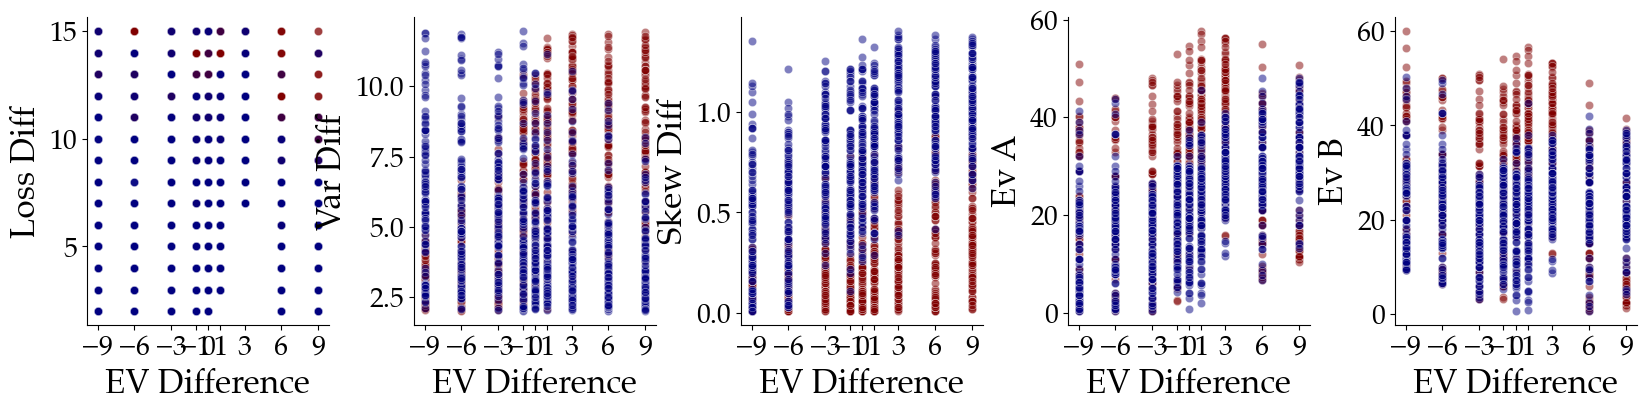

In [41]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, gridspec_kw={'hspace': 0.35, 'wspace': 0.35})

features = ['loss_diff', 'var_diff', 'skew_diff', 'ev_a', 'ev_b']

for col, feat in enumerate(features):
    # Top row: Old
    sns.scatterplot(
        data=old_lotteries,
        x='ev_diff',
        y=np.abs(old_lotteries[feat]),
        color='maroon',
        alpha=0.5,
        ax=axes[col],
    )
    sns.scatterplot(
        data=new_lotteries,
        x='ev_diff',
        y=np.abs(new_lotteries[feat]),
        color='navy',
        alpha=0.5,
        ax=axes[col],
    )
    axes[col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[col].set_xlabel('')
    # if col == 1:
    #     axes[0, col].set_title('Old', fontsize=FONTSIZE_1, pad=15)
    # else:
    #     axes[0, col].set_title('')
    axes[col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[col].set_xticks(ev_diff)
    # sns.despine(ax=axes[0, col])

    # # Bottom row: New
    # sns.scatterplot(
    #     data=lotteries_new,
    #     x='ev_diff',
    #     y=lotteries_new[feat],
    #     color='navy',
    #     alpha=0.5,
    #     ax=axes[1, col],
    # )
    axes[col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[col].set_xlabel('EV Difference', fontsize=FONTSIZE_2)
    # if col == 1:
    #     axes[1, col].set_title('New', fontsize=FONTSIZE_1, pad=15)
    # else:
    #     axes[1, col].set_title('')
    # axes[1, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    # axes[1, col].set_xticks(ev_diff)
    sns.despine()